### <mark><u>_**Configure the number of cores for the initial Load, with incremental 2 is enough**_</u></mark>

In [1]:
%%configure
{"vCores": 16}

In [2]:
!pip install -q  --disable-pip-version-check semantic-link-labs
!pip install -q   duckdb --upgrade
!pip install -q   duckrun
notebookutils.session.restartPython()

sys.exit called with value 0. The interpreter will be restarted.


### <u>_**<mark>Define the Workspace where to store data and the number of files to process initially</mark>**_</u>

In [3]:
ws                    = 'tmp'
nbr_days_download     =  2800

In [4]:
lh                    = 'data'
schema                = 'aemo'
sql_folder            = 'https://github.com/djouallah/fabric_demo/raw/refs/heads/main/transformation/'
bim_url               = "https://raw.githubusercontent.com/djouallah/fabric_demo/refs/heads/main/semantic_model/directlake.bim"
remaining_files       =  max(0,nbr_days_download - 60)
semantic_model_dl     =  "DL"
semantic_model_dq     =  "DQ"
semantic_model_du     =  "DU"

Minor Modification from https://github.com/microsoft/fabric-toolbox/tree/main/tools/FabricLoadTestTool

In [5]:
from   deltalake            import DeltaTable
from   deltalake.writer     import write_deltalake
from   notebookutils.common import configs
from   psutil               import *
import sempy_labs as labs
import duckrun
from   psutil import *
import matplotlib.pyplot  as plt
import time 
import duckdb
import os
core              = cpu_count()
configs.tokenCacheEnabled = False
Nbr_threads = core * 2
print(core)

16


In [6]:
try:
    labs.import_notebook_from_web(overwrite=False,notebook_name="RunPerfScenario" , url="https://raw.githubusercontent.com/djouallah/fabric_demo/refs/heads/main/Benchmark/RunPerfScenario.ipynb")
except Exception as e:
    print(f"Error: {e}")

Error: 🔴 The 'RunPerfScenario' already exists within the 'largedata' workspace and 'overwrite' is set to False.


# Update Data

In [7]:
con = duckrun.connect(f"{ws}/{lh}.lakehouse/{schema}", sql_folder)

Connecting to Lakehouse...
🔍 Discovering tables in schema 'aemo'...

📊 Found 8 tables:
   aemo: calendar, duid, mstdatetime, price, price_today, scada, scada_today, summary

✅ Ready - 8/8 tables available



In [8]:
nightly =[
              
              ('scrapingv2', (["https://nemweb.com.au/Reports/Current/Daily_Reports/"],["Reports/Current/Daily_Reports/"],nbr_days_download,ws,lh,Nbr_threads)),
              ('price','append'),
              ('scada','append'),
              ('download_excel',("raw/", ws,lh)),
              ('duid','overwrite'),
              ('calendar','ignore'),
              ('mstdatetime','ignore'),
              ('summary__backfill','overwrite')
         ]

intraday = [
              ('scrapingv2', (["http://nemweb.com.au/Reports/Current/DispatchIS_Reports/","http://nemweb.com.au/Reports/Current/Dispatch_SCADA/" ],
                            ["Reports/Current/DispatchIS_Reports/","Reports/Current/Dispatch_SCADA/"],
                             288, ws,lh,Nbr_threads)),
              ('price_today','append'),
              ('scada_today','append'),
              ('duid','ignore'),
              ('summary__incremental', 'append')            
          ]

history_download = [('scrapingv2',(["https://github.com/djouallah/fabric_demo/tree/main/data/archive/*"],["Reports/Current/Daily_Reports/"],remaining_files,ws,lh,Nbr_threads))]

history_process = [('scada','append'),('price','append'),('summary__backfill_archive','append')]

In [9]:
#create lakehouse if not exists
con.run([('create_lakehouse_if_not_existsv2', (lh,ws))])


Task 1/1: create_lakehouse_if_not_existsv2
Running Python: create_lakehouse_if_not_existsv2('data', 'tmp')
Attempting to get lakehouse 'data' with workspace_id: 67d3feed-4012-4319-b231-c184031d3617
Lakehouse found - returning 1
✅ Python 'create_lakehouse_if_not_existsv2' completed

✅ All tasks completed successfully


True

In [10]:
%%time
con.run(nightly)


Task 1/8: scrapingv2
Running Python: scrapingv2(['https://nemweb.com.au/Reports/Current/Daily_Reports/'], ['Reports/Current/Daily_Reports/'], 2800, 'tmp', 'data', 32)
https://nemweb.com.au/Reports/Current/Daily_Reports/ - 0 files extracted (all 60 files already downloaded)
✅ Python 'scrapingv2' completed

⏹️  Python task 1 returned 0 - stopping pipeline execution
   Remaining tasks (7) will not be executed
CPU times: user 85.8 ms, sys: 7.76 ms, total: 93.6 ms
Wall time: 1.32 s


False

In [11]:
%%time
con.run(intraday)


Task 1/5: scrapingv2
Running Python: scrapingv2(['http://nemweb.com.au/Reports/Current/DispatchIS_Reports/', 'http://nemweb.com.au/Reports/Current/Dispatch_SCADA/'], ['Reports/Current/DispatchIS_Reports/', 'Reports/Current/Dispatch_SCADA/'], 288, 'tmp', 'data', 32)
Failed to download PUBLIC_DISPATCHSCADA_202510101100_0000000484230313.zip: HTTP 403
Failed to download PUBLIC_DISPATCHIS_202510101055_0000000484229854.zip: HTTP 403
Flushed 6 files to disk and updated log Reports/Current/Dispatch_SCADA/download_log.csv
Flushed 6 files to disk and updated log Reports/Current/DispatchIS_Reports/download_log.csv
http://nemweb.com.au/Reports/Current/Dispatch_SCADA/ - 6 files extracted and uploaded
http://nemweb.com.au/Reports/Current/DispatchIS_Reports/ - 6 files extracted and uploaded
✅ Python 'scrapingv2' completed

Task 2/5: price_today


FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

✅ SQL 'price_today' → 'price_today' (append) (engine=pyarrow)

Task 3/5: scada_today
✅ SQL 'scada_today' → 'scada_today' (append) (engine=pyarrow)

Task 4/5: duid
Table duid exists. Skipping (mode='ignore')
✅ SQL 'duid' → 'duid' (ignore) (engine=pyarrow)

Task 5/5: summary__incremental
✅ SQL 'summary__incremental' → 'summary' (append) (engine=pyarrow)

✅ All tasks completed successfully
CPU times: user 4.14 s, sys: 767 ms, total: 4.91 s
Wall time: 20.2 s


True

In [12]:
%%time
con.run([('deploy_modelv5', (ws,lh,schema,semantic_model_dl,bim_url,"directlake"))])
con.run([('deploy_modelv5', (ws,lh,schema,semantic_model_dq,bim_url,"directquery"))])
con.run([('deploy_modelv5', (ws,lh,schema,semantic_model_du,bim_url,"dual"))])


Task 1/1: deploy_modelv5
Running Python: deploy_modelv5('tmp', 'data', 'aemo', 'DL', 'https://raw.githubusercontent.com/djouallah/fabric_demo/refs/heads/main/semantic_model/directlake.bim', 'directlake')
Enhanced Power BI Semantic Model Deployment
Deployment Mode: DIRECTLAKE

[Step 1/8] Getting workspace information...
✓ Found workspace 'tmp': 67d3feed-4012-4319-b231-c184031d3617

[Step 2/8] Checking if dataset 'DL' exists...
⚠️  Dataset 'DL' already exists in this workspace

⚠️  Dataset 'DL' already exists - exiting without changes
   No deployment or refresh will be performed

ℹ️  Deployment Skipped - Dataset Already Exists

Dataset Name:     DL
Workspace:        tmp
Workspace ID:     67d3feed-4012-4319-b231-c184031d3617

→ The semantic model already exists in this workspace
→ To redeploy, please delete the existing dataset first
→ Or use a different dataset name
✅ Python 'deploy_modelv5' completed

✅ All tasks completed successfully

Task 1/1: deploy_modelv5
Running Python: deploy_

True

In [13]:
%%time
if remaining_files > 0:
    con.run(history_download)


Task 1/1: scrapingv2
Running Python: scrapingv2(['https://github.com/djouallah/fabric_demo/tree/main/data/archive/*'], ['Reports/Current/Daily_Reports/'], 2740, 'tmp', 'data', 32)
Error processing PUBLIC_DAILY_201912310000_20200101040502.zip: File is not a zip file
https://github.com/djouallah/fabric_demo/tree/main/data/archive/* - No files to upload
✅ Python 'scrapingv2' completed

⏹️  Python task 1 returned 0 - stopping pipeline execution
   Remaining tasks (0) will not be executed
CPU times: user 244 ms, sys: 18.2 ms, total: 262 ms
Wall time: 1.82 s


In [14]:
%%time
if remaining_files > 0:
    con.run(history_process)


Task 1/3: scada

❌ Task 1 failed: Parser Error: read_csv cannot take NULL list as parameter
CPU times: user 1.27 s, sys: 47.1 ms, total: 1.32 s
Wall time: 2.36 s


In [15]:
totalrows=(con.sql("select count(*) from summary").fetchone()[0])
print(totalrows)

128721986


In [24]:
con.get_stats(schema)

Processing 8 tables: ['calendar', 'duid', 'mstdatetime', 'price', 'price_today', 'scada', 'scada_today', 'summary']


,tbl,total_rows,num_files,num_row_group,average_row_group,file_size_MB,vorder,timestamp
0,scada,323443868.0,49,169.0,1913870,3436.0,False,2025-10-10 01:24:17
1,summary,128721986.0,21,69.0,1865537,589.0,False,2025-10-10 01:24:17
2,price,4177710.0,10,11.0,379792,510.0,False,2025-10-10 01:24:17
3,scada_today,338736.0,44,44.0,7699,3.0,False,2025-10-10 01:24:17
4,price_today,6615.0,44,44.0,151,2.0,False,2025-10-10 01:24:17
5,calendar,3197.0,1,1.0,3197,1.0,False,2025-10-10 01:24:17
6,duid,626.0,1,1.0,626,1.0,False,2025-10-10 01:24:17
7,mstdatetime,288.0,1,1.0,288,1.0,False,2025-10-10 01:24:17


# Test

<mark>_**I can't automate dual mode connection, please do it manually as it will fall back to diretquery**_</mark>

In [17]:
load_test_name     = "loadtest"                                                                                           
queryfile          = "https://raw.githubusercontent.com/djouallah/fabric_demo/refs/heads/main/Benchmark/PowerBIPerformanceData.json"    
concurrent_threads = core                                                                      
delay_sec          = 4                                                                               
iterations         = 1    
cache              = 1   
delta_path         = f"abfss://{ws}@onelake.dfs.fabric.microsoft.com/{lh}.Lakehouse/Tables/dbo/results"   
conn = notebookutils.data.connect_to_artifact(lh, ws)
conn.query(f"ALTER DATABASE {lh} SET RESULT_SET_CACHING ON;")
def run_test(workspace,dataset):
    if 'Collapse Here':
        ts=time.strftime("%Y%m%d-%H%M%S")
        loadtestId:str = f"{load_test_name}-{ts}"
        print(loadtestId)
        users = []
        args = { 
            "xmla_endpoint" : f"powerbi://api.powerbi.com/v1.0/myorg/{workspace}", #defaults to current workspace's endpoint
            "perf_analyzer_filename" : queryfile , 
            "model" : dataset,
            "roles" : None,
            "customdata" : None,
            "effective_username" : None,
            "iterations" : iterations,
            "delay_sec" : 1,
            "loadtestId" : loadtestId ,
            "threadId" : 0 ,
            "concurrent_threads" : concurrent_threads,
            "useRootDefaultLakehouse": True ,
            "cache" : cache ,
            "delta_path" : delta_path,
            "totalrows"  : totalrows
        }

        activity =  {
                    "name": "RunPerfScenario", # activity name, must be unique
                    "path": "RunPerfScenario", # notebook path
                    "timeoutPerCellInSeconds": 90000, # max timeout for each cell, default to 90 seconds
                    "args": {"param1": "value1"}, # notebook parameters
                    "workspace": None, # workspace name, default to current workspace
                    "retry": 0, # max retry times, default to 0
                    "retryIntervalInSeconds": 0, # retry interval, default to 0 seconds
                    "dependencies": [] # list of activity names that this activity depends on
                }


        DAG = {
            "activities": [],
            "timeoutInSeconds": 43200, # max timeout for the entire pipeline, default to 12 hours
            "concurrency": 25 # max number of notebooks to run concurrently, default to 25
        }
        DAG["concurrency"] = concurrent_threads

        for i in range(concurrent_threads):
            a = activity.copy()
            a["name"] = f"{a['name']}_{i}"
            this_args = args.copy()
            if (len(users)>0):
                user = users[i%len(users)]
                this_args["effective_username"] = user 
            this_args["threadId"] = i
            a["args"] = this_args
            DAG["activities"].append(a)
        print('running load test')
        try:
            results = notebookutils.notebook.runMultiple(DAG) 
        except Exception as e:
            first_result = results[list(e.result)[0]]
            print('Notebook failed.  First Result Exception: ')
            print(first_result.get('exception',None))
        print('load test complete')

In [18]:
import random
semantic_model_sql = random.choice([semantic_model_du, semantic_model_dq])
print(semantic_model_sql)

DU


In [19]:
for workspace, dataset in [(ws,semantic_model_sql),(ws,semantic_model_dl)] :
    try:
        print(dataset)
        run_test(workspace,dataset)
    except Exception as e:
       print(f"Error: {e}")

DU
loadtest-20251010-011823
running load test


load test complete
DL
loadtest-20251010-012124
running load test


Error: cannot access local variable 'results' where it is not associated with a value


# Result

In [20]:
dt = DeltaTable(delta_path)
dt.optimize.compact()
duckdb.sql(f""" 
                CREATE or replace persistent SECRET onelake ( TYPE AZURE, PROVIDER ACCESS_TOKEN, ACCESS_TOKEN '{notebookutils.credentials.getToken('storage')}') ;
                create or replace table raw
                as select
                *exclude(model),
                model as Engine ,
                from delta_scan('{delta_path}')
                where
                cache = 1
                and concurrent_threads = {concurrent_threads}
                and iterations = 1           
 """)

In [21]:
duckdb.sql(""" 
         select
         Engine ,
         concurrent_threads ,
         round(avg(duration),2)                 as avg ,
         round(QUANTILE_CONT(duration, 0.90),2) AS p90_value,
         round(geomean(duration),2)             AS geomean
 from raw 
       group by all
       order by geomean asc
        """).show()

┌─────────┬────────────────────┬────────┬───────────┬─────────┐
│ Engine  │ concurrent_threads │  avg   │ p90_value │ geomean │
│ varchar │       int64        │ double │  double   │ double  │
├─────────┼────────────────────┼────────┼───────────┼─────────┤
│ DL      │                 16 │   0.19 │      0.26 │    0.09 │
│ DU      │                 16 │   1.51 │      2.36 │    0.32 │
│ DQ      │                 16 │   1.78 │      2.38 │    0.45 │
└─────────┴────────────────────┴────────┴───────────┴─────────┘



In [22]:
summary= duckdb.sql("""
    SELECT
          strftime(DATE_TRUNC('hour', start_time_dt + INTERVAL '10 hours'), '%Y-%m-%d %H%M') AS hour, 
          Engine ,
          concurrent_threads ,
          max(totalrows)                          AS totalrows ,
          COUNT(*)                                AS count,
          round(QUANTILE_CONT(duration , 0.90),2) AS p90_value,
          round(geomean(duration),2)              AS geomean
      FROM raw
      GROUP BY all
      ORDER BY 1 desc
""")
summary.show(max_width=190)

┌─────────────────┬─────────┬────────────────────┬───────────┬───────┬───────────┬─────────┐
│      hour       │ Engine  │ concurrent_threads │ totalrows │ count │ p90_value │ geomean │
│     varchar     │ varchar │       int64        │   int64   │ int64 │  double   │ double  │
├─────────────────┼─────────┼────────────────────┼───────────┼───────┼───────────┼─────────┤
│ 2025-10-10 1100 │ DL      │                 16 │ 128721986 │   592 │      0.19 │    0.08 │
│ 2025-10-10 1100 │ DU      │                 16 │ 128721986 │   592 │       1.8 │    0.31 │
│ 2025-10-10 1000 │ DL      │                 16 │ 128720678 │  1184 │      0.17 │    0.08 │
│ 2025-10-10 1000 │ DQ      │                 16 │ 128720678 │   592 │       2.0 │    0.41 │
│ 2025-10-10 1000 │ DU      │                 16 │ 128720678 │   592 │      2.26 │    0.33 │
│ 2025-10-10 0800 │ DQ      │                 16 │ 128714386 │   592 │      2.15 │    0.48 │
│ 2025-10-10 0800 │ DL      │                 16 │ 128714386 │   592 │

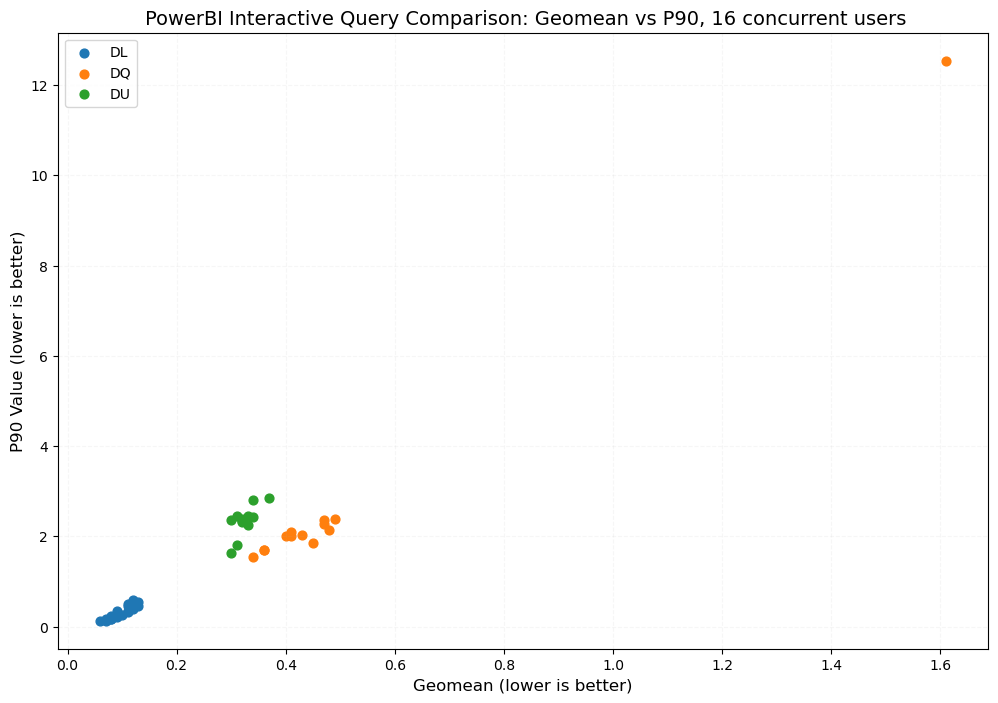

In [23]:
df = duckdb.sql(" select Engine, p90_value,geomean from summary  ").df()
plt.figure(figsize=(12,8 ))
for model, group in df.groupby("Engine"):
    plt.scatter(group["geomean"], group["p90_value"], label=model, s=40)

plt.xlabel("Geomean (lower is better)", fontsize=12)
plt.ylabel("P90 Value (lower is better)", fontsize=12)
plt.title(f" PowerBI Interactive Query Comparison: Geomean vs P90, {concurrent_threads} concurrent users", fontsize=14)
plt.legend()
plt.grid(True, linestyle="--", alpha=0.1)
plt.show()